In [32]:
###### %load_ext autoreload
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from interpret.glassbox import ExplainableBoostingRegressor
import sys
sys.path.insert(0, '..')

from  benchmark_regression_classification import *
from sklearn.metrics import mean_squared_error
from interpret import show
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import seaborn as sns

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
dataset = "synthetic_corr"


df_X = None
df_output = None
df_std = None
models = {}
for model_name in ["EBM_GAM", "EGB_XGB_GAM_CYCLIC_CYCLIC", "EGB_XGB_GAM_BEST_FIT_BEST_FIT", "Spline",
                   "EBM_GA2M", "EGB_XGB_GA2M_CYCLIC_CYCLIC","EGB_XGB_GA2M_BEST_FIT_BEST_FIT"]:

    model = save_load_model(dataset, model_name, 0)
    models[model_name] = model
    if model is None:
        continue
    if df_X is None:
        num_f = len(model.feature_names)
        d = {model.feature_names[i]:model.preprocessor_._get_bin_labels(i) for i in range(num_f)}
        df_X = pd.DataFrame(data=d)
        df_output = df_X
        df_std = df_X
    scores, stds = predict_score_with_each_feature(model, df_X, add_std=True)
    scores = scores.drop("offset", axis=1)
    scores = scores[[col for col in scores.columns if not " x " in col]]
    df_output = df_output.join(scores, rsuffix="_"+model_name)
    df_std = df_std.join(stds, rsuffix="_"+model_name)
    #display(df_output.head())
    #display(df_std.head())

x_to_loc = gen_synth_data_correlation_exp()['full']['x_to_loc']
for name in x_to_loc.keys():
    df_output[name + "_y"] = x_to_loc[name](df_output[name])
    df_output[name + "_y"] -= np.mean(df_output[name + "_y"])
display(df_output.head())

,x1,x2,x3,x4,x5,x1_EBM_GAM,x2_EBM_GAM,x3_EBM_GAM,x4_EBM_GAM,x5_EBM_GAM,...,x2_EGB_XGB_GA2M_CYCLIC_CYCLIC,x3_EGB_XGB_GA2M_CYCLIC_CYCLIC,x4_EGB_XGB_GA2M_CYCLIC_CYCLIC,x5_EGB_XGB_GA2M_CYCLIC_CYCLIC,x1_EGB_XGB_GA2M_BEST_FIT_BEST_FIT,x2_EGB_XGB_GA2M_BEST_FIT_BEST_FIT,x3_EGB_XGB_GA2M_BEST_FIT_BEST_FIT,x4_EGB_XGB_GA2M_BEST_FIT_BEST_FIT,x5_EGB_XGB_GA2M_BEST_FIT_BEST_FIT,x1_y
0,0.000546,0.000546,0.001924,0.000907,0.000907,0.008028,0.009832,-0.266033,-0.127406,-0.129575,...,0.004578,-0.276516,-0.135631,-0.131925,0.009961,0.0,-0.286342,-0.265298,0.0,-0.019361
1,0.004278,0.004278,0.003454,0.009770,0.009770,0.008076,0.010734,-0.222972,-0.125529,-0.124961,...,0.005986,-0.224001,-0.128473,-0.124274,0.009962,0.0,-0.217145,-0.240569,0.0,-0.008167
2,0.011571,0.011571,0.008949,0.016237,0.016237,0.008162,0.010295,-0.225364,-0.133770,-0.132602,...,0.004305,-0.204352,-0.137577,-0.135594,0.009270,0.0,-0.195594,-0.267797,0.0,0.013686
3,0.014421,0.014421,0.011776,0.019996,0.019996,0.005080,0.007213,-0.221115,-0.130887,-0.128171,...,-0.000202,-0.224225,-0.126570,-0.125463,0.008457,0.0,-0.226319,-0.251074,0.0,0.022212
4,0.017697,0.017697,0.016098,0.022495,0.022495,0.017656,0.019738,-0.228070,-0.133236,-0.133143,...,0.010843,-0.229666,-0.132768,-0.131954,0.014921,0.0,-0.229489,-0.261902,0.0,0.031992


x1 x1_EBM_GAM


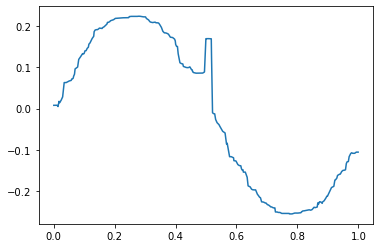

x1 x1_EGB_XGB_GAM_CYCLIC_CYCLIC


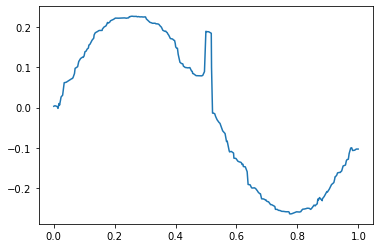

x1 x1_EGB_XGB_GAM_BEST_FIT_BEST_FIT


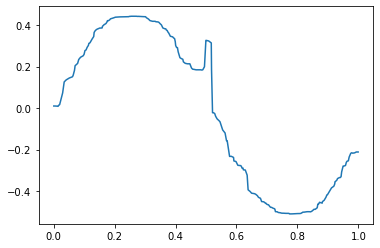

x1 x1_Spline


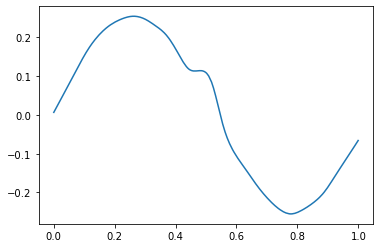

x1 x1_EBM_GA2M


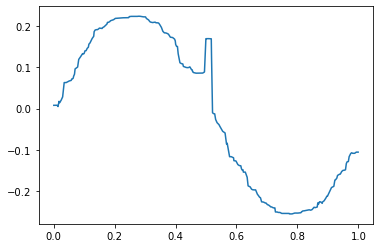

x1 x1_EGB_XGB_GA2M_CYCLIC_CYCLIC


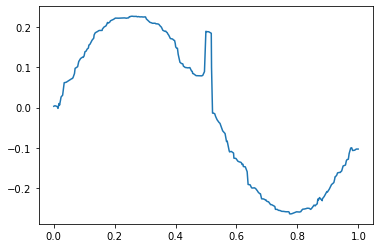

x1 x1_EGB_XGB_GA2M_BEST_FIT_BEST_FIT


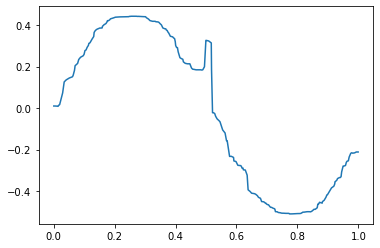

x1 x1_y


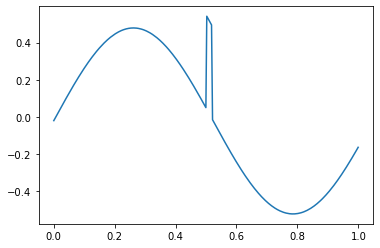

x2 x2_EBM_GAM


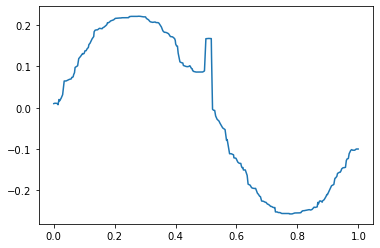

x2 x2_EGB_XGB_GAM_CYCLIC_CYCLIC


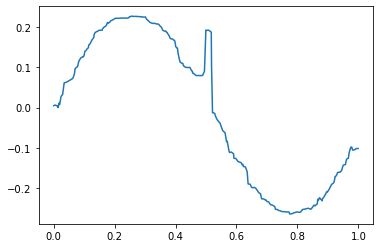

x2 x2_EGB_XGB_GAM_BEST_FIT_BEST_FIT


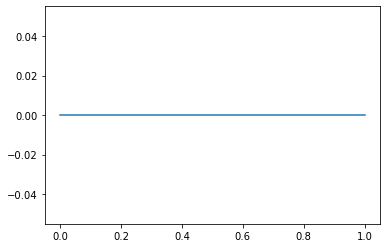

x2 x2_Spline


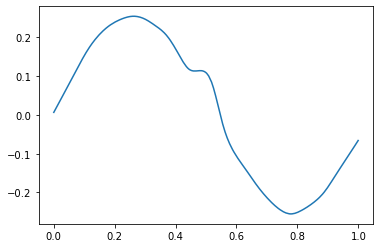

x2 x2_EBM_GA2M


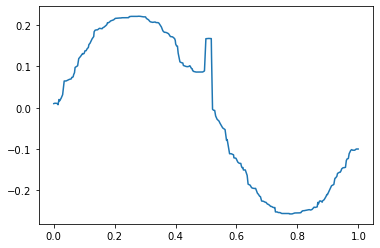

x2 x2_EGB_XGB_GA2M_CYCLIC_CYCLIC


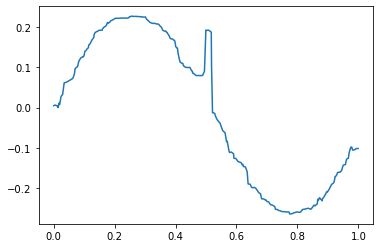

x2 x2_EGB_XGB_GA2M_BEST_FIT_BEST_FIT


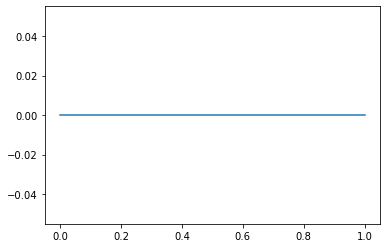

x3 x3_EBM_GAM


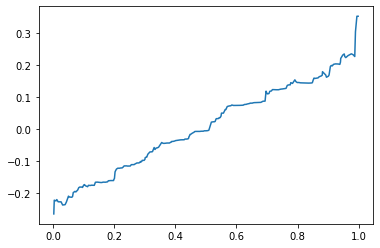

x3 x3_EGB_XGB_GAM_CYCLIC_CYCLIC


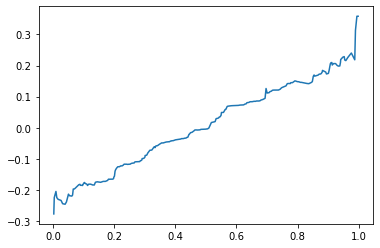

x3 x3_EGB_XGB_GAM_BEST_FIT_BEST_FIT


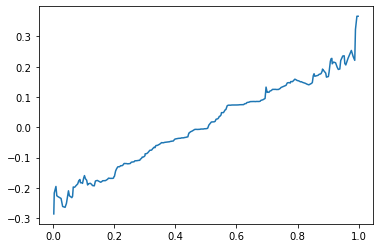

x3 x3_Spline


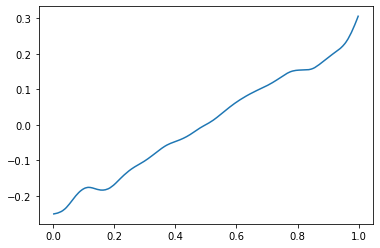

x3 x3_EBM_GA2M


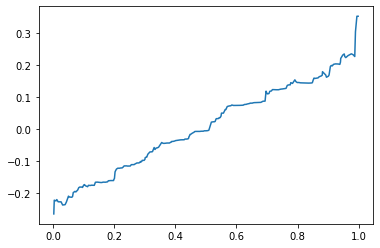

x3 x3_EGB_XGB_GA2M_CYCLIC_CYCLIC


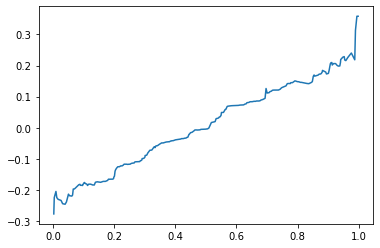

x3 x3_EGB_XGB_GA2M_BEST_FIT_BEST_FIT


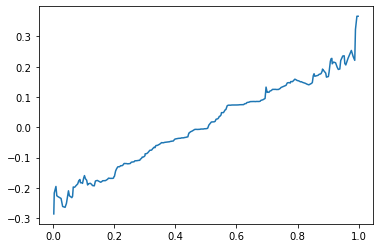

In [15]:

for f in ["x1", "x2", "x3"]:
    for col in df_output.columns:
        if not col.startswith(f+"_"):
            continue
        print(f, col)
        fig, ax = plt.subplots()
        the_ax = df_output.set_index(f)[col].plot().axes
        the_ax.set_xlabel('')
        #display(df_output[f].head())
        #display(df_std[f].head())
        plt.show()

(31, 31)

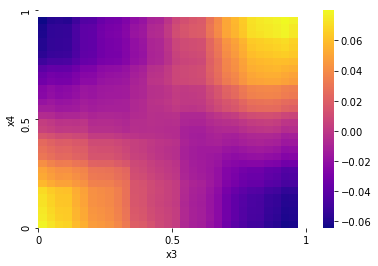

(31, 31)

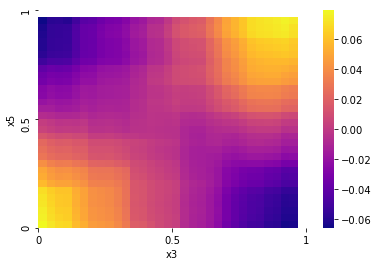

(31, 31)

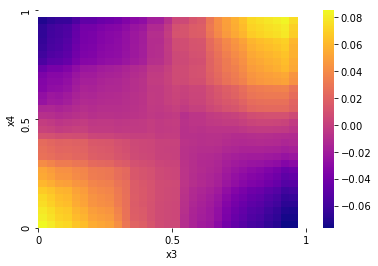

(31, 31)

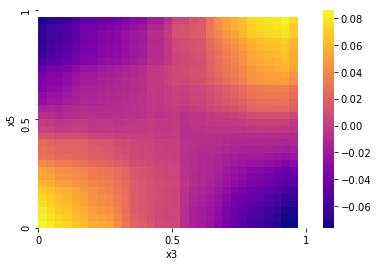

(31, 31)

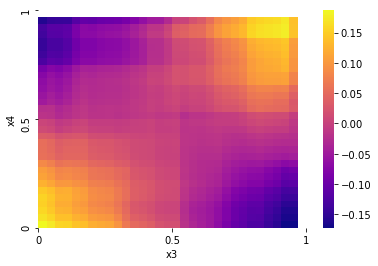

(31, 31)

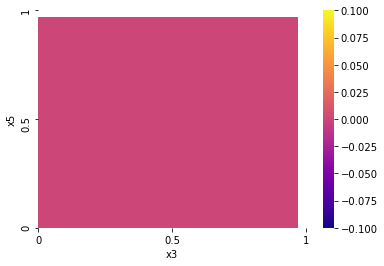

In [16]:
def print_heatmap(data, var1="X1", var2="X2", algo="", name_postfix=""):
    import math
    
    #xlabels = [0, float(int(bin_labels_left[32]*10))/10]
    #ylabels = [0, float(int(bin_labels_right[32]*10))/10]
    xlabels = [0, 0.5, 1]
    ylabels = [0, 0.5, 1]
    xticks = yticks = [0, 16, 32]
    
    display(data.shape)
    df = pd.DataFrame(data.T)#[1:,1:]
    df = df.rename_axis(index=var1, columns=var2)
    ax=sns.heatmap(df, cmap="plasma",cbar=True)

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_xticklabels(xlabels)
    ax.set_yticklabels(ylabels)
    ax.invert_yaxis()
    name = var2 +" vs. " + var1 
    name += name_postfix
    base_path = "results_explantions/synthetic/"
    #ax =ax.set_title(name)
    figure_ = ax.get_figure()

    #figure_.savefig(base_path+"".join(x for x in name if x.isalnum())+"_"+algo+".png", dpi=400)
    plt.show()
    
def print_heatmap_inter(ebm, inter_number, is_egb=True):
    name_postfix = ""
    if is_egb:
        feature_indexes = ebm.interactions_chosen[inter_number]
        model_graph = ebm.outputs_inter_[inter_number]
        names = ebm.feature_names
        algo = "EGM"
        feature_group_index = ebm.n_features_in_+inter_number
        percent_imp = (100*np.mean(np.abs(model_graph))/
                           sum(ebm.feature_importances_))
        name_postfix = (" (Importance=%.1f" % percent_imp) +"%)"
    else:
        feature_indexes = ebm.feature_groups_[inter_number]
        model_graph = ebm.additive_terms_[inter_number]
        names = ebm.feature_names
        algo="EBM"
        
    model_graph = model_graph[1:, 1:]
    bin_labels_left = ebm.preprocessor_._get_bin_labels(feature_indexes[0])
    bin_labels_right = ebm.preprocessor_._get_bin_labels(feature_indexes[1])

    print_heatmap(model_graph, var1=names[feature_indexes[1]], var2=names[feature_indexes[0]], algo=algo)
    #print_heatmap(model_graph, var1="feat1", var2="feat3", algo=algo)
              

#dict_keys(['ebm_rand=[True, True]_interactions=0_inner=10', 'XGBoost_rand=[True, True]_interactions=0_l2=0,4_inner=10', 'XGBoost_rand=[False, False]_interactions=0_l2=0,4_inner=10', 'spline'])                 
print_heatmap_inter(models["EBM_GA2M"], inter_number=5, is_egb=False)
print_heatmap_inter(models["EBM_GA2M"], inter_number=6, is_egb=False)

print_heatmap_inter(models["EGB_XGB_GA2M_CYCLIC_CYCLIC"], inter_number=0, is_egb=True)
print_heatmap_inter(models["EGB_XGB_GA2M_CYCLIC_CYCLIC"], inter_number=1, is_egb=True)

print_heatmap_inter(models["EGB_XGB_GA2M_BEST_FIT_BEST_FIT"], inter_number=0, is_egb=True)
print_heatmap_inter(models["EGB_XGB_GA2M_BEST_FIT_BEST_FIT"], inter_number=1, is_egb=True)

(32, 32)

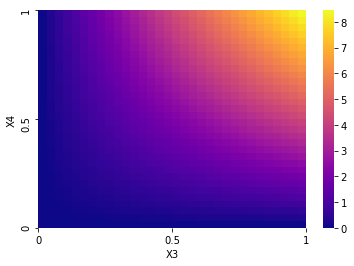

(32, 32)

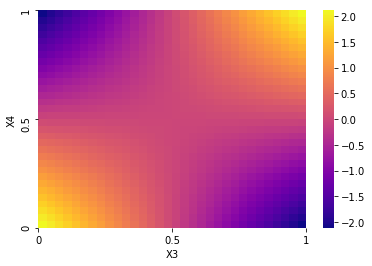

(32, 32)

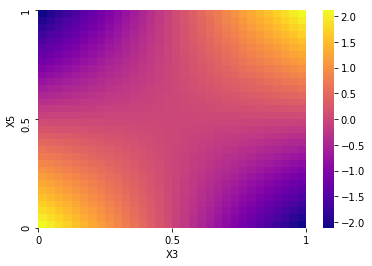

Text(0.5, 0, '')

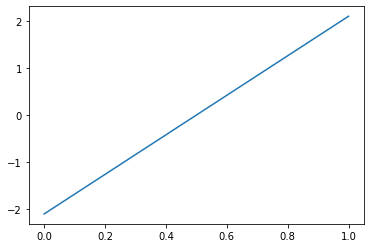

In [17]:
import purify
def get_mul():
    mul = np.zeros((32,32))
    for i in range(32):
        for j in range(32):
            mul[i,j] = 9*i*j/(32*32)
    return mul

intercept, m1, m2, mat, i = purify.purify(get_mul().astype(float))

#print_heatmap(get_sin().astype(float), var1="X5", var2="X4", ismean=True, algo="Synthetic")
#intercept, m1, m2, mat, i = purify(get_sin().astype(float))
print_heatmap(get_mul().astype(float), var1="X4", var2="X3", algo="Synthetic_purified")

print_heatmap(mat, var1="X4", var2="X3", algo="Synthetic_purified")
print_heatmap(mat, var1="X5", var2="X3", algo="Synthetic_purified")
x4_pure = pd.DataFrame(m1)
x4_pure["x"] = np.linspace(0, 1.0, num=x4_pure.shape[0])
x4_pure.set_index("x")[0].plot().axes.set_xlabel('')

In [24]:
from sklearn.model_selection import ParameterGrid
dataset = load_nhanesi_data()
#X, Y, x_to_loc, _ = gen_synth_data_correlation_exp(noise_f=0, add_inter=True, n=1000)
X = dataset['full']['X']
Y = dataset['full']['y']

X_train, X_val, y_train, y_val = train_test_split(
                X, Y, test_size=0.2, random_state=42)

dataset = "NHANES I"

df_X = None
df_output = None
df_std = None
models = {}
for model_name in ["EGB_XGB_GAM_CYCLIC_CYCLIC", "EGB_XGB_GA2M_CYCLIC_CYCLIC"]:

    model = save_load_model(dataset, model_name, 0)
    models[model_name] = model
    if model is None:
        continue      
    if df_X is None:
        num_f = len(model.feature_names)
        d = {model.feature_names[i]:model.preprocessor_._get_bin_labels(i) for i in range(num_f)}
        #df_X = pd.DataFrame(data=d)
        df_X = pd.DataFrame(dict([ (k,pd.Series(v)) for k,v in d.items() ]))
        df_output = df_X
        df_std = df_X
    scores, stds = predict_score_with_each_feature(model, df_X, add_std=True)
    display(stds.head())
    scores = scores.drop("offset", axis=1)
    scores = scores[[col for col in scores.columns if not " x " in col]]
    df_output = df_output.join(scores, rsuffix="_"+model_name)
    df_std = df_std.join(stds, rsuffix="_"+model_name)
    display(df_output.head())
    display(df_std.head())

display(df_output.head())

,offset,sex,age,physical_activity,serum_albumin,alkaline_phosphatase,alkaline_phosphatase_isUnacceptable,alkaline_phosphatase_isTestnotdone,SGOT,SGOT_isUnacceptable,...,urine_hematest_isLarge,urine_hematest_isBlankbutapplicable,sedimentation_rate,sedimentation_rate_isBlankbutapplicable,uric_acid,uric_acid_isUnacceptable,uric_acid_isTestnotdone,systolic_blood_pressure,pulse_pressure,bmi
0,0.9811,0.007028,0.067317,0.043362,0.036388,0.013221,0.001311,0.000619,0.005022,0.000875,...,0.000782,0.001058,0.013260,0.001352,0.009118,0.000638,0.000596,0.151708,0.091978,0.063860
1,0.9811,0.010266,0.069582,0.007614,0.040920,0.022948,0.050797,0.048103,0.006477,0.034021,...,0.159898,0.021534,0.010793,0.017102,0.013511,0.142711,0.044589,0.151708,0.092265,0.073159
2,0.9811,0.007028,0.069329,0.004390,0.044474,0.018004,0.001311,0.000619,0.007030,0.000875,...,0.000782,0.001058,0.010005,0.001352,0.016128,0.000638,0.000596,0.151708,0.091289,0.061570
3,0.9811,0.007028,0.070092,0.014842,0.044018,0.015007,0.001311,0.000619,0.008564,0.000875,...,0.000782,0.001058,0.008997,0.001352,0.015010,0.000638,0.000596,0.148751,0.078612,0.060034
4,0.9811,0.007028,0.067989,0.025221,0.031909,0.015605,0.001311,0.000619,0.009440,0.000875,...,0.000782,0.001058,0.005702,0.001352,0.015252,0.000638,0.000596,0.082175,0.060514,0.039035


,sex,age,physical_activity,serum_albumin,alkaline_phosphatase,alkaline_phosphatase_isUnacceptable,alkaline_phosphatase_isTestnotdone,SGOT,SGOT_isUnacceptable,SGOT_isTestnotdone,...,urine_hematest_isLarge_EGB_XGB_GAM_CYCLIC_CYCLIC,urine_hematest_isBlankbutapplicable_EGB_XGB_GAM_CYCLIC_CYCLIC,sedimentation_rate_EGB_XGB_GAM_CYCLIC_CYCLIC,sedimentation_rate_isBlankbutapplicable_EGB_XGB_GAM_CYCLIC_CYCLIC,uric_acid_EGB_XGB_GAM_CYCLIC_CYCLIC,uric_acid_isUnacceptable_EGB_XGB_GAM_CYCLIC_CYCLIC,uric_acid_isTestnotdone_EGB_XGB_GAM_CYCLIC_CYCLIC,systolic_blood_pressure_EGB_XGB_GAM_CYCLIC_CYCLIC,pulse_pressure_EGB_XGB_GAM_CYCLIC_CYCLIC,bmi_EGB_XGB_GAM_CYCLIC_CYCLIC
0,Female,25.0,1.0,2.70,4.8,False,False,0.270,False,False,...,0.000048,-0.000503,-0.108985,-0.006837,-0.003814,0.002509,0.002780,0.105822,-0.189778,0.897453
1,Male,25.5,1.5,2.95,6.5,True,True,0.530,True,True,...,-0.009822,0.010236,-0.111993,0.086507,-0.010545,-0.560866,-0.207911,0.105822,-0.187633,0.885958
2,NaN,26.5,2.5,3.05,15.5,NaN,NaN,0.635,NaN,NaN,...,0.000048,-0.000503,-0.105373,-0.006837,-0.018691,0.002509,0.002780,0.105822,-0.166568,0.580429
3,NaN,27.5,3.5,3.15,16.5,NaN,NaN,0.790,NaN,NaN,...,0.000048,-0.000503,-0.090174,-0.006837,-0.026011,0.002509,0.002780,0.108714,-0.181777,0.587468
4,NaN,28.5,6.0,3.25,17.5,NaN,NaN,0.830,NaN,NaN,...,0.000048,-0.000503,-0.090504,-0.006837,-0.025270,0.002509,0.002780,0.205112,-0.185075,0.441040


,sex,age,physical_activity,serum_albumin,alkaline_phosphatase,alkaline_phosphatase_isUnacceptable,alkaline_phosphatase_isTestnotdone,SGOT,SGOT_isUnacceptable,SGOT_isTestnotdone,...,urine_hematest_isLarge_EGB_XGB_GAM_CYCLIC_CYCLIC,urine_hematest_isBlankbutapplicable_EGB_XGB_GAM_CYCLIC_CYCLIC,sedimentation_rate_EGB_XGB_GAM_CYCLIC_CYCLIC,sedimentation_rate_isBlankbutapplicable_EGB_XGB_GAM_CYCLIC_CYCLIC,uric_acid_EGB_XGB_GAM_CYCLIC_CYCLIC,uric_acid_isUnacceptable_EGB_XGB_GAM_CYCLIC_CYCLIC,uric_acid_isTestnotdone_EGB_XGB_GAM_CYCLIC_CYCLIC,systolic_blood_pressure_EGB_XGB_GAM_CYCLIC_CYCLIC,pulse_pressure_EGB_XGB_GAM_CYCLIC_CYCLIC,bmi_EGB_XGB_GAM_CYCLIC_CYCLIC
0,Female,25.0,1.0,2.70,4.8,False,False,0.270,False,False,...,0.000782,0.001058,0.013260,0.001352,0.009118,0.000638,0.000596,0.151708,0.091978,0.063860
1,Male,25.5,1.5,2.95,6.5,True,True,0.530,True,True,...,0.159898,0.021534,0.010793,0.017102,0.013511,0.142711,0.044589,0.151708,0.092265,0.073159
2,NaN,26.5,2.5,3.05,15.5,NaN,NaN,0.635,NaN,NaN,...,0.000782,0.001058,0.010005,0.001352,0.016128,0.000638,0.000596,0.151708,0.091289,0.061570
3,NaN,27.5,3.5,3.15,16.5,NaN,NaN,0.790,NaN,NaN,...,0.000782,0.001058,0.008997,0.001352,0.015010,0.000638,0.000596,0.148751,0.078612,0.060034
4,NaN,28.5,6.0,3.25,17.5,NaN,NaN,0.830,NaN,NaN,...,0.000782,0.001058,0.005702,0.001352,0.015252,0.000638,0.000596,0.082175,0.060514,0.039035


,offset,sex,age,physical_activity,serum_albumin,alkaline_phosphatase,alkaline_phosphatase_isUnacceptable,alkaline_phosphatase_isTestnotdone,SGOT,SGOT_isUnacceptable,...,urine_hematest_isLarge,urine_hematest_isBlankbutapplicable,sedimentation_rate,sedimentation_rate_isBlankbutapplicable,uric_acid,uric_acid_isUnacceptable,uric_acid_isTestnotdone,systolic_blood_pressure,pulse_pressure,bmi
0,0.980021,0.007041,0.069197,0.044697,0.035754,0.011756,0.001306,0.000618,0.004793,0.000867,...,0.000771,0.001079,0.014354,0.001316,0.009094,0.000617,0.000598,0.145088,0.092999,0.064554
1,0.980021,0.010284,0.070947,0.007856,0.039327,0.022631,0.050593,0.048042,0.006691,0.033722,...,0.157574,0.021949,0.011508,0.016647,0.014053,0.137820,0.044694,0.145088,0.093157,0.071611
2,0.980021,0.007041,0.070621,0.004304,0.043638,0.018162,0.001306,0.000618,0.007277,0.000867,...,0.000771,0.001079,0.010896,0.001316,0.016723,0.000617,0.000598,0.145088,0.091577,0.061677
3,0.980021,0.007041,0.071004,0.014709,0.043670,0.015420,0.001306,0.000618,0.008465,0.000867,...,0.000771,0.001079,0.009062,0.001316,0.015852,0.000617,0.000598,0.141799,0.079067,0.059925
4,0.980021,0.007041,0.068369,0.027022,0.035559,0.014958,0.001306,0.000618,0.009110,0.000867,...,0.000771,0.001079,0.005376,0.001316,0.016162,0.000617,0.000598,0.075806,0.061354,0.038211


,sex,age,physical_activity,serum_albumin,alkaline_phosphatase,alkaline_phosphatase_isUnacceptable,alkaline_phosphatase_isTestnotdone,SGOT,SGOT_isUnacceptable,SGOT_isTestnotdone,...,urine_hematest_isLarge_EGB_XGB_GA2M_CYCLIC_CYCLIC,urine_hematest_isBlankbutapplicable_EGB_XGB_GA2M_CYCLIC_CYCLIC,sedimentation_rate_EGB_XGB_GA2M_CYCLIC_CYCLIC,sedimentation_rate_isBlankbutapplicable_EGB_XGB_GA2M_CYCLIC_CYCLIC,uric_acid_EGB_XGB_GA2M_CYCLIC_CYCLIC,uric_acid_isUnacceptable_EGB_XGB_GA2M_CYCLIC_CYCLIC,uric_acid_isTestnotdone_EGB_XGB_GA2M_CYCLIC_CYCLIC,systolic_blood_pressure_EGB_XGB_GA2M_CYCLIC_CYCLIC,pulse_pressure_EGB_XGB_GA2M_CYCLIC_CYCLIC,bmi_EGB_XGB_GA2M_CYCLIC_CYCLIC
0,Female,25.0,1.0,2.70,4.8,False,False,0.270,False,False,...,0.000045,-0.000516,-0.109295,-0.006783,-0.001969,0.002520,0.002802,0.111921,-0.188529,0.898832
1,Male,25.5,1.5,2.95,6.5,True,True,0.530,True,True,...,-0.009122,0.010499,-0.112225,0.085830,-0.008660,-0.563359,-0.209492,0.111921,-0.185702,0.885979
2,NaN,26.5,2.5,3.05,15.5,NaN,NaN,0.635,NaN,NaN,...,0.000045,-0.000516,-0.105812,-0.006783,-0.017110,0.002520,0.002802,0.111921,-0.164870,0.578407
3,NaN,27.5,3.5,3.15,16.5,NaN,NaN,0.790,NaN,NaN,...,0.000045,-0.000516,-0.090282,-0.006783,-0.025559,0.002520,0.002802,0.115748,-0.181673,0.586010
4,NaN,28.5,6.0,3.25,17.5,NaN,NaN,0.830,NaN,NaN,...,0.000045,-0.000516,-0.090380,-0.006783,-0.024505,0.002520,0.002802,0.209976,-0.185088,0.440173


,sex,age,physical_activity,serum_albumin,alkaline_phosphatase,alkaline_phosphatase_isUnacceptable,alkaline_phosphatase_isTestnotdone,SGOT,SGOT_isUnacceptable,SGOT_isTestnotdone,...,urine_hematest_isLarge_EGB_XGB_GA2M_CYCLIC_CYCLIC,urine_hematest_isBlankbutapplicable_EGB_XGB_GA2M_CYCLIC_CYCLIC,sedimentation_rate_EGB_XGB_GA2M_CYCLIC_CYCLIC,sedimentation_rate_isBlankbutapplicable_EGB_XGB_GA2M_CYCLIC_CYCLIC,uric_acid_EGB_XGB_GA2M_CYCLIC_CYCLIC,uric_acid_isUnacceptable_EGB_XGB_GA2M_CYCLIC_CYCLIC,uric_acid_isTestnotdone_EGB_XGB_GA2M_CYCLIC_CYCLIC,systolic_blood_pressure_EGB_XGB_GA2M_CYCLIC_CYCLIC,pulse_pressure_EGB_XGB_GA2M_CYCLIC_CYCLIC,bmi_EGB_XGB_GA2M_CYCLIC_CYCLIC
0,Female,25.0,1.0,2.70,4.8,False,False,0.270,False,False,...,0.000771,0.001079,0.014354,0.001316,0.009094,0.000617,0.000598,0.145088,0.092999,0.064554
1,Male,25.5,1.5,2.95,6.5,True,True,0.530,True,True,...,0.157574,0.021949,0.011508,0.016647,0.014053,0.137820,0.044694,0.145088,0.093157,0.071611
2,NaN,26.5,2.5,3.05,15.5,NaN,NaN,0.635,NaN,NaN,...,0.000771,0.001079,0.010896,0.001316,0.016723,0.000617,0.000598,0.145088,0.091577,0.061677
3,NaN,27.5,3.5,3.15,16.5,NaN,NaN,0.790,NaN,NaN,...,0.000771,0.001079,0.009062,0.001316,0.015852,0.000617,0.000598,0.141799,0.079067,0.059925
4,NaN,28.5,6.0,3.25,17.5,NaN,NaN,0.830,NaN,NaN,...,0.000771,0.001079,0.005376,0.001316,0.016162,0.000617,0.000598,0.075806,0.061354,0.038211


,sex,age,physical_activity,serum_albumin,alkaline_phosphatase,alkaline_phosphatase_isUnacceptable,alkaline_phosphatase_isTestnotdone,SGOT,SGOT_isUnacceptable,SGOT_isTestnotdone,...,urine_hematest_isLarge_EGB_XGB_GA2M_CYCLIC_CYCLIC,urine_hematest_isBlankbutapplicable_EGB_XGB_GA2M_CYCLIC_CYCLIC,sedimentation_rate_EGB_XGB_GA2M_CYCLIC_CYCLIC,sedimentation_rate_isBlankbutapplicable_EGB_XGB_GA2M_CYCLIC_CYCLIC,uric_acid_EGB_XGB_GA2M_CYCLIC_CYCLIC,uric_acid_isUnacceptable_EGB_XGB_GA2M_CYCLIC_CYCLIC,uric_acid_isTestnotdone_EGB_XGB_GA2M_CYCLIC_CYCLIC,systolic_blood_pressure_EGB_XGB_GA2M_CYCLIC_CYCLIC,pulse_pressure_EGB_XGB_GA2M_CYCLIC_CYCLIC,bmi_EGB_XGB_GA2M_CYCLIC_CYCLIC
0,Female,25.0,1.0,2.70,4.8,False,False,0.270,False,False,...,0.000045,-0.000516,-0.109295,-0.006783,-0.001969,0.002520,0.002802,0.111921,-0.188529,0.898832
1,Male,25.5,1.5,2.95,6.5,True,True,0.530,True,True,...,-0.009122,0.010499,-0.112225,0.085830,-0.008660,-0.563359,-0.209492,0.111921,-0.185702,0.885979
2,NaN,26.5,2.5,3.05,15.5,NaN,NaN,0.635,NaN,NaN,...,0.000045,-0.000516,-0.105812,-0.006783,-0.017110,0.002520,0.002802,0.111921,-0.164870,0.578407
3,NaN,27.5,3.5,3.15,16.5,NaN,NaN,0.790,NaN,NaN,...,0.000045,-0.000516,-0.090282,-0.006783,-0.025559,0.002520,0.002802,0.115748,-0.181673,0.586010
4,NaN,28.5,6.0,3.25,17.5,NaN,NaN,0.830,NaN,NaN,...,0.000045,-0.000516,-0.090380,-0.006783,-0.024505,0.002520,0.002802,0.209976,-0.185088,0.440173


sex sex_EGB_XGB_GAM_CYCLIC_CYCLIC


0    Female
1      Male
2       NaN
3       NaN
4       NaN
Name: sex, dtype: object

,sex,sex_EGB_XGB_GAM_CYCLIC_CYCLIC
0,Female,-0.240596
1,Male,0.351445


array([0.0070281 , 0.01026613])

array(['Female', 'Male'], dtype=object)

/tmp/ipykernel_7523/1534463875.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(df[f].values)


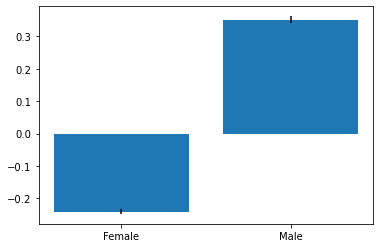

sex sex_EGB_XGB_GA2M_CYCLIC_CYCLIC


0    Female
1      Male
2       NaN
3       NaN
4       NaN
Name: sex, dtype: object

,sex,sex_EGB_XGB_GA2M_CYCLIC_CYCLIC
0,Female,-0.24062
1,Male,0.35148


array([0.00704055, 0.01028431])

array(['Female', 'Male'], dtype=object)

/tmp/ipykernel_7523/1534463875.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(df[f].values)


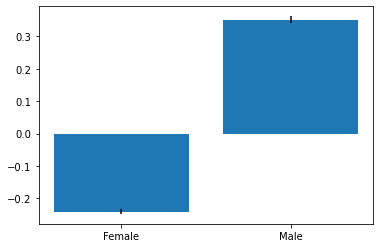

age age_EGB_XGB_GAM_CYCLIC_CYCLIC


0    25.0
1    25.5
2    26.5
3    27.5
4    28.5
Name: age, dtype: float64

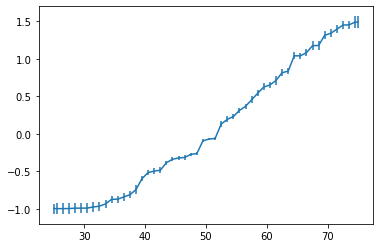

age age_EGB_XGB_GA2M_CYCLIC_CYCLIC


0    25.0
1    25.5
2    26.5
3    27.5
4    28.5
Name: age, dtype: float64

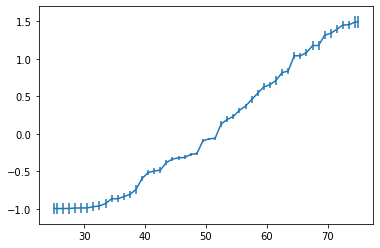

systolic_blood_pressure systolic_blood_pressure_EGB_XGB_GAM_CYCLIC_CYCLIC


0    80.0
1    81.0
2    83.0
3    85.5
4    87.0
Name: systolic_blood_pressure, dtype: float64

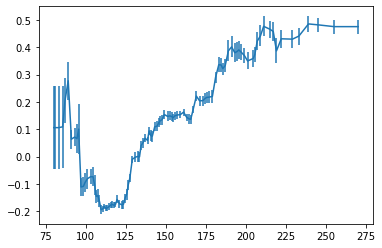

systolic_blood_pressure systolic_blood_pressure_EGB_XGB_GA2M_CYCLIC_CYCLIC


0    80.0
1    81.0
2    83.0
3    85.5
4    87.0
Name: systolic_blood_pressure, dtype: float64

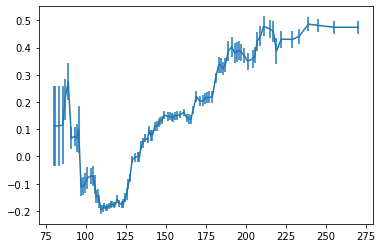

serum_protein serum_protein_EGB_XGB_GAM_CYCLIC_CYCLIC


0    4.40
1    5.25
2    5.35
3    5.45
4    5.55
Name: serum_protein, dtype: float64

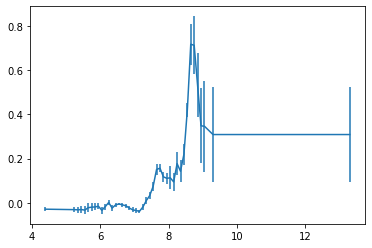

serum_protein serum_protein_EGB_XGB_GA2M_CYCLIC_CYCLIC


0    4.40
1    5.25
2    5.35
3    5.45
4    5.55
Name: serum_protein, dtype: float64

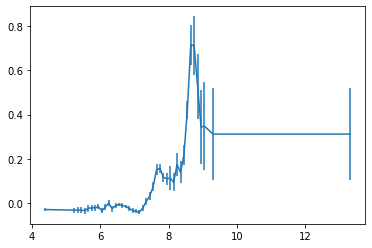

In [25]:
for f in ["sex", "age", "systolic_blood_pressure", "serum_protein"]:
    for col in df_output.columns:
        if not col.startswith(f+"_"):
            continue
        print(f, col)
        fig, ax = plt.subplots()
        #the_ax = df_output.set_index(f)[col].plot().axes
        #the_ax.set_xlabel('')
        display(df_output[f].head())
        #display(df_std[f].head())
        df = df_output[[f, col]].dropna()

        if f=="sex":
            #f_output.set_index(f).dropna()[col].plot.bar(yerr=df_std.dropna()[col])
            display(df.head())
            ax.bar(df[f].index, df[col].values, yerr=df_std.head(df.shape[0])[col].values)
            #ax.errorbar(df[f].index, df[col].values, yerr=df_s.head(df.shape[0])[col].values)
            display(df_std.head(df.shape[0])[col].values)
            display(df[f].values)
            ax.set_xticklabels(df[f].values) 
            ax.set_xticks([0,1]) 
        else:
            ax.errorbar(df[f].values, df[col].values, yerr=df_std.head(df.shape[0])[col].values)

        plt.show()

(31, 31)

(31, 31)

3

3

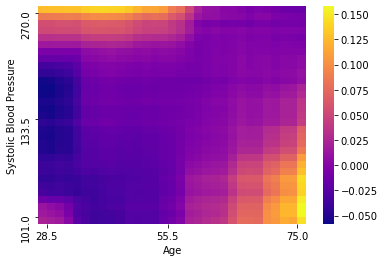

In [26]:
def print_heatmap(data, bin_labels_left, bin_labels_right, var1="X1", var2="X2", algo="", name_postfix=""):
    import math
    
    #xlabels = [0, float(int(bin_labels_left[32]*10))/10]
    #ylabels = [0, float(int(bin_labels_right[32]*10))/10]
    ylabels = bin_labels_left[1:]
    xlabels = bin_labels_right[1:]
    xticks = [1, 15, 30]
    yticks = [1, 15, 30]
    
    xlabels=[xlabels[i] for i in xticks]
    ylabels=[ylabels[i] for i in yticks]

    var1 = "Systolic Blood Pressure"
    var2 = "Age"
    
    display(data.shape)
    df = pd.DataFrame(data.T)#[1:,1:]
    df = df.rename_axis(index=var1, columns=var2)
    display(df.shape, len(ylabels), len(xlabels))
    ax=sns.heatmap(df, cmap="plasma",cbar=True)

    ax.set_xticks(yticks)
    ax.set_yticks(xticks)
    ax.set_xticklabels(ylabels)
    ax.set_yticklabels(xlabels)
    ax.invert_yaxis()

    name = var2 +" vs. " + var1 
    name += name_postfix
    base_path = "results_explantions/synthetic/"
    #ax =ax.set_title(name)
    figure_ = ax.get_figure()

    #figure_.savefig(base_path+"".join(x for x in name if x.isalnum())+"_"+algo+".png", dpi=400)
    plt.show()
def print_heatmap_inter(ebm, inter_number, is_egb=True):
    name_postfix = ""
    if is_egb:
        feature_indexes = ebm.interactions_chosen[inter_number]
        model_graph = ebm.outputs_inter_[inter_number]
        names = ebm.feature_names
        algo = "EGM"
        feature_group_index = ebm.n_features_in_+inter_number
        percent_imp = (100*np.mean(np.abs(model_graph))/
                           sum(ebm.feature_importances_))
        name_postfix = (" (Importance=%.1f" % percent_imp) +"%)"
    else:
        feature_indexes = ebm.feature_groups_[inter_number]
        model_graph = ebm.additive_terms_[inter_number]
        names = ebm.feature_names
        algo="EBM"
        
    model_graph = model_graph[1:, 1:]
    bin_labels_left = ebm.preprocessor_inter._get_bin_labels(feature_indexes[0])
    bin_labels_right = ebm.preprocessor_inter._get_bin_labels(feature_indexes[1])

    print_heatmap(model_graph, var1=names[feature_indexes[1]], var2=names[feature_indexes[0]],
                  bin_labels_left=bin_labels_left, bin_labels_right=bin_labels_right, algo=algo)
    
    

print_heatmap_inter(model, inter_number=3, is_egb=True)

In [33]:
dataset = "california housing monotone"

model_mono = save_load_model(dataset, "EGB_XGB_GA2M_CYCLIC_CYCLIC", 0)

show(model_mono.explain_global())


dataset = "california housing"

model_non_mono = save_load_model(dataset, "EGB_XGB_GA2M_CYCLIC_CYCLIC", 0)

show(model_non_mono.explain_global())

<!-- http://127.0.0.1:7001/140634966483200/ -->

<!-- http://127.0.0.1:7001/140634939909648/ -->

(31, 31)

(31, 31)

3

3

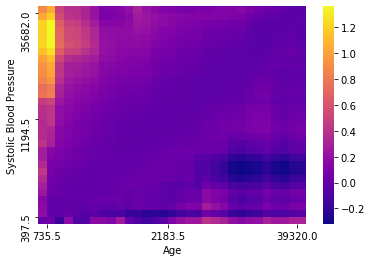

In [34]:
print_heatmap_inter(model_mono, inter_number=3)
